# Diabetes Dataset — Gradient Descent from Scratch

This notebook demonstrates linear regression on the **Scikit-learn Diabetes dataset** using two approaches:

- `SGDRegressor` from Scikit-learn
- A custom Gradient Descent implementation from scratch

The goal is to understand how gradient descent minimizes the cost function and compare it with Scikit-learn's implementation.

## 1. Import Libraries

Import all the required libraries for data handling, visualization, preprocessing, model training, and evaluation.

In [61]:
import pandas as py
import numpy as np 
import matplotlib.pyplot as mp
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import SGDRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error,mean_squared_error
from sklearn.preprocessing import StandardScaler
from GradientDescent import GradientDescent

## 2. Load the Diabetes Dataset

Load the built-in diabetes dataset from Scikit-learn.

In [13]:
diabetes = load_diabetes()

## 3. Explore the Dataset

Inspect the available keys and convert the feature matrix into a Pandas DataFrame for easier analysis.

In [14]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [15]:
df = py.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 4. Define Features and Target

For this experiment:

- **Target (`y`)** → `bp` (Blood Pressure)
- **Features (`X`)** → All remaining attributes

In [16]:
X = df.drop(columns=['bp'])
y = df['bp']

## 5. Train–Test Split

Split the dataset into **80% training** and **20% testing** while keeping the split reproducible using a fixed random state.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    random_state=42,
    train_size=0.8
)

## 6. Feature Scaling

Normalize the input features using **StandardScaler**.

> The scaler is fitted only on the training data and then applied to the test data to prevent data leakage.

In [18]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

## 7. Linear Regression using SGDRegressor

Train multiple models with different **alpha** values and compare their performance using:

- MAE
- MSE
- R² Score

This helps observe the effect of regularization.

In [19]:
alpha = [0.000001,0.0001,0.001,0.01,0.1,1]
for i in alpha:
    model = SGDRegressor(alpha=i)
    model.fit(X_train,y_train)
    y_predict = model.predict(X_test)
    print(f'------For value of alpha [{i}]–------\n')
    # print(f'Predicted Values are: \n{y_predict}')
    print(f'R2 score: {r2_score(y_test,y_predict):.3f}')
    print(f'Root Mean Square Error: {root_mean_squared_error(y_test,y_predict):.3f}')
    print(f'Mean Absolute Error: {mean_absolute_error(y_test,y_predict):.3f}')
    print(f'Mean Squared Error: {mean_squared_error(y_test,y_predict):.3f}\n')

------For value of alpha [1e-06]–------

R2 score: 0.383
Root Mean Square Error: 0.034
Mean Absolute Error: 0.027
Mean Squared Error: 0.001

------For value of alpha [0.0001]–------

R2 score: 0.381
Root Mean Square Error: 0.034
Mean Absolute Error: 0.027
Mean Squared Error: 0.001

------For value of alpha [0.001]–------

R2 score: 0.391
Root Mean Square Error: 0.034
Mean Absolute Error: 0.026
Mean Squared Error: 0.001

------For value of alpha [0.01]–------

R2 score: 0.377
Root Mean Square Error: 0.035
Mean Absolute Error: 0.027
Mean Squared Error: 0.001

------For value of alpha [0.1]–------

R2 score: 0.389
Root Mean Square Error: 0.034
Mean Absolute Error: 0.027
Mean Squared Error: 0.001

------For value of alpha [1]–------

R2 score: 0.354
Root Mean Square Error: 0.035
Mean Absolute Error: 0.029
Mean Squared Error: 0.001



## 8. Feature Coefficients

Display the learned coefficient of each feature to understand its influence on the target variable.

In [20]:
for i,c in zip(X.columns, model.coef_):
    print(i,c)

age 0.004744691654591193
sex 0.0031376874025588115
bmi 0.00676561945815609
s1 0.0022476426788178706
s2 8.53281144112983e-05
s3 0.000523310228637935
s4 -0.0002287010807303013
s5 0.0050129084544085455
s6 0.005339023151148816


## 9. Predicted vs Actual Values

A scatter plot comparing predicted blood pressure values with the actual values.

Ideally, the points should lie close to the diagonal line.

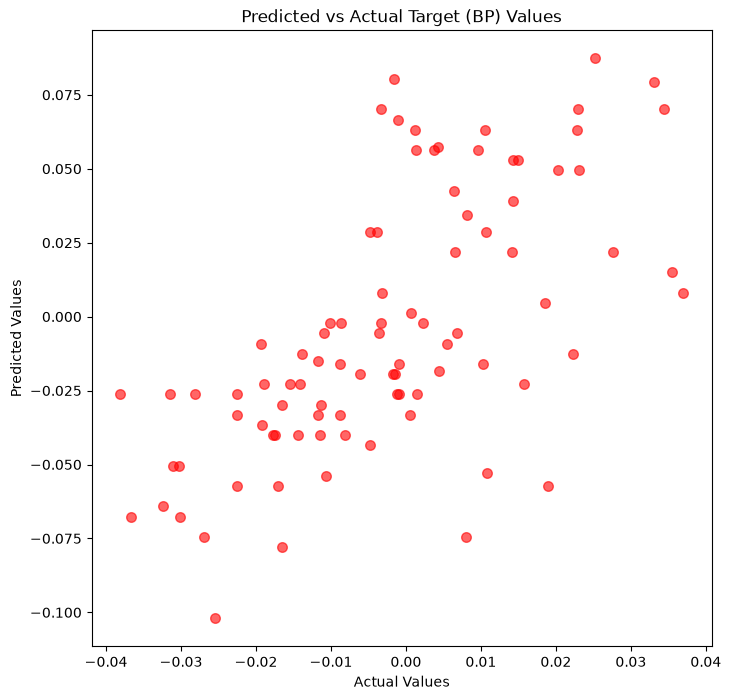

In [21]:
mp.figure(figsize=(8,8))
mp.scatter(y_predict,y_test,c='red',alpha=0.6,s=48)
mp.title('Predicted vs Actual Target (BP) Values')
mp.xlabel('Actual Values')
mp.ylabel('Predicted Values')
mp.show()

## 10. Residual Plot

Visualize prediction errors (residuals).

A good linear model generally produces residuals that are randomly distributed around zero.

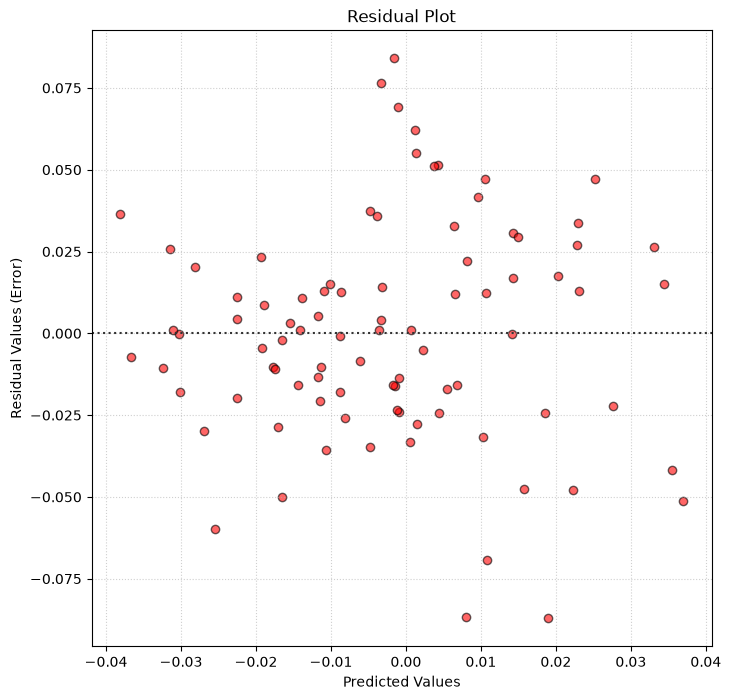

In [27]:
mp.figure(figsize=(8,8))
sns.residplot(
    x=y_predict, 
    y=y_test, 
    color='red', 
    scatter_kws={'alpha': 0.6, 'edgecolors': 'k'}
)
mp.title('Residual Plot')
mp.xlabel('Predicted Values')
mp.ylabel('Residual Values (Error)')
mp.grid(True,linestyle=':',alpha=0.6)
mp.show()

# Gradient Descent from Scratch

## 11. Use a Single Feature (BMI)

To visualize gradient descent easily, we use only the **BMI** feature.

This reduces the problem to **Simple Linear Regression**:

<math block value="y = mx + c"/>

In [51]:
bmi_index = X.columns.get_loc('bmi')
X_train_new = X_train[:,bmi_index]
X_test_new = X_test[:,bmi_index]
y_train_new = y_train.values
y_test_new = y_test.values
print(f'Training sample size: {len(X_train_new)}')

Training sample size: 353


## 12. Implement Gradient Descent

The custom implementation includes:

- Cost Function (Mean Squared Error)
- Gradient calculation
- Parameter updates for **slope (m)** and **intercept (c)**
- Training history for visualization

In [ ]:
#using our defined gradient descent

def _costFunction(m,c,x,y):
    n = len(x)
    h = m*x + c
    # return (1/n) * GradientDescent.sum((h - y) ** 2)
    return (1/n) * gd.sum((h-y)** 2)


gd = GradientDescent(alfa=0.01, iterations=200, tolerance=1e-12)
gd.fit(X_train_new.reshape(-1,1),y_train_new,track_history=True)

slope = gd.m[0]
intercept = gd.c

cost = _costFunction(slope,intercept,X_train_new,y_train_new)
history = np.array([[h_m[0],h_c,h_cost] for h_m,h_c,h_cost in gd.history])


## 13. Training History

Inspect how the parameters and cost change after each epoch during optimization.

In [ ]:
print(history)

[[0.00000000e+00 0.00000000e+00 2.34395252e-03]
 [3.81691282e-04 2.35877636e-05 2.32947430e-03]
 [7.55748739e-04 4.67037720e-05 2.31556942e-03]
 [1.12232505e-03 6.93574602e-05 2.30221518e-03]
 [1.48156983e-03 9.15580746e-05 2.28938976e-03]
 [1.83362971e-03 1.13314677e-04 2.27707223e-03]
 [2.17864840e-03 1.34636147e-04 2.26524247e-03]
 [2.51676672e-03 1.55531188e-04 2.25388117e-03]
 [2.84812267e-03 1.76008327e-04 2.24296978e-03]
 [3.17285149e-03 1.96075924e-04 2.23249048e-03]
 [3.49108575e-03 2.15742170e-04 2.22242616e-03]
 [3.80295531e-03 2.35015090e-04 2.21276039e-03]
 [4.10858749e-03 2.53902552e-04 2.20347738e-03]
 [4.40810702e-03 2.72412264e-04 2.19456198e-03]
 [4.70163617e-03 2.90551783e-04 2.18599962e-03]
 [4.98929472e-03 3.08328511e-04 2.17777634e-03]
 [5.27120011e-03 3.25749704e-04 2.16987870e-03]
 [5.54746739e-03 3.42822474e-04 2.16229381e-03]
 [5.81820933e-03 3.59553788e-04 2.15500928e-03]
 [6.08353642e-03 3.75950476e-04 2.14801321e-03]
 [6.34355698e-03 3.92019230e-04 2.141294

## 14. Create the Parameter Grid

Generate a mesh of possible **m** and **c** values to visualize the loss surface around the learned solution.

In [62]:
m_vals = np.linspace(slope-10,slope+10,100)
c_vals = np.linspace(intercept-10,intercept+10,100)
M,C = np.meshgrid(m_vals,c_vals)

## 15. Compute Cost Surface

Evaluate the cost function for every combination of slope and intercept in the parameter grid.

In [74]:
Z = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i,j] = _costFunction(M[i,j],C[i,j],X_train_new,y_train_new)

## 16. 3D Cost Surface

The 3D surface represents the optimization landscape.

- X-axis → Slope (m)
- Y-axis → Intercept (c)
- Z-axis → Cost (MSE)

The red point indicates the parameters learned by gradient descent.

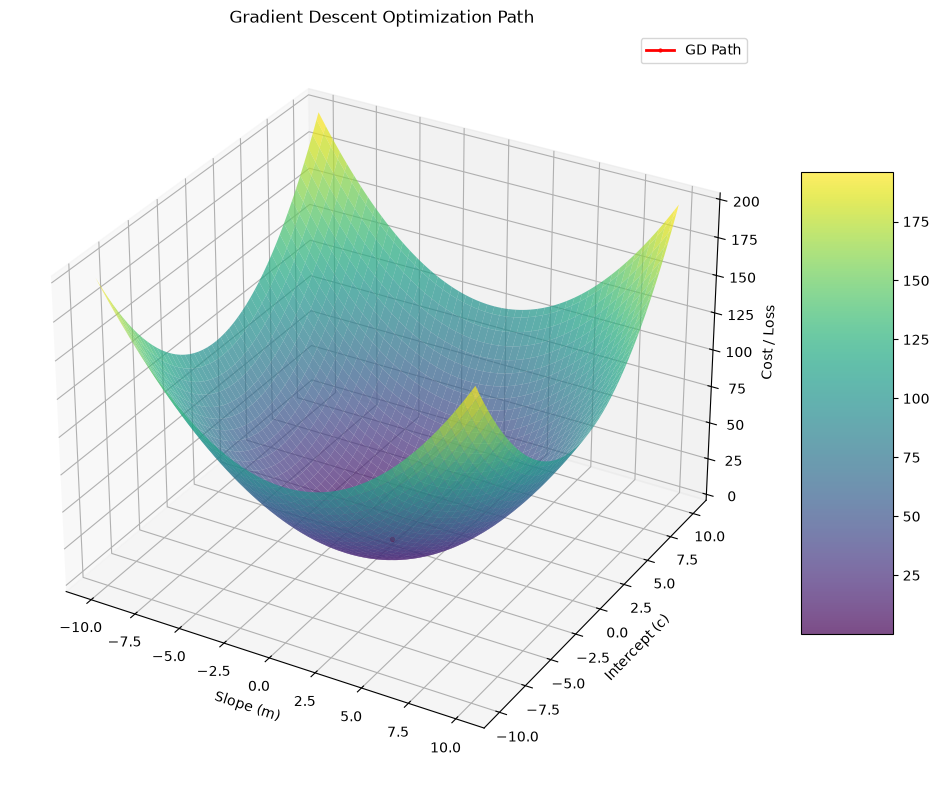

In [76]:
fig, ax = mp.subplots(figsize=(12, 12), subplot_kw={'projection': '3d'})

surface = ax.plot_surface(M, C, Z, cmap='viridis', edgecolor='none', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5)

ax.plot(history[:, 0], history[:, 1], history[:, 2], color='red', marker='o', markersize=2, linewidth=2, label='GD Path')

ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (c)')
ax.set_zlabel('Cost / Loss')
ax.set_title('Gradient Descent Optimization Path')

mp.legend()
mp.show()

## 17. Cost vs Epoch

Plot the decrease in the cost function over training epochs.

A continuously decreasing curve indicates that gradient descent is successfully converging toward the minimum.

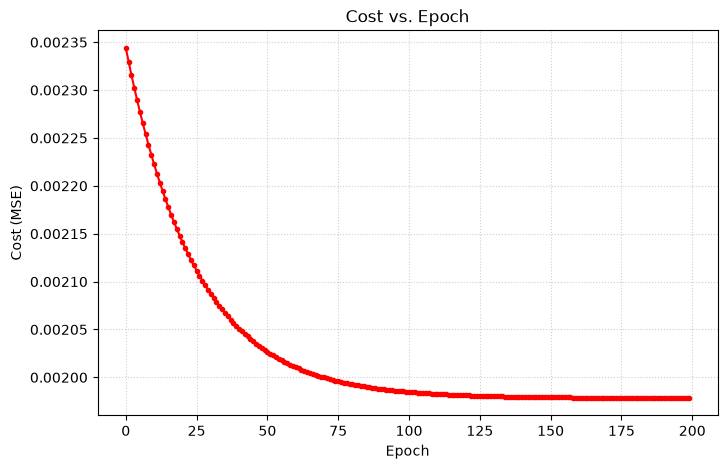

In [78]:
mp.figure(figsize=(8, 5))
mp.plot(history[:, 2], color='red', marker='o', markersize=3)
mp.title('Cost vs. Epoch')
mp.xlabel('Epoch')
mp.ylabel('Cost (MSE)')
mp.grid(True, linestyle=':', alpha=0.6)
mp.show()

# Conclusion

This project helped bridge the gap between using Scikit-learn models and understanding the mathematics behind them.

### What I learned

- Loaded and explored the **Scikit-learn Diabetes dataset** using Pandas.
- Selected features and target variables for a regression problem.
- Performed an **80–20 train-test split** and applied **StandardScaler** correctly by fitting only on the training data.
- Trained a linear regression model using **SGDRegressor** and evaluated it with **MAE, MSE, and R² Score**.
- Analyzed feature coefficients to understand the contribution of each input feature.
- Built a **Linear Regression model from scratch** using Gradient Descent.
- Implemented the cost function, gradient calculation, and parameter updates for slope and intercept.
- Visualized the optimization process through **training history**, **3D cost surface**, and **cost vs epoch** plots.

### Module Reusability

Instead of rewriting the Gradient Descent logic, the previously built **self-made Gradient Descent implementation** was reused as an **external Python module**. The notebook imports its functions and class, demonstrating modular programming and code reusability while keeping the implementation clean and maintainable.

Overall, this notebook reinforced both the practical workflow of machine learning and the underlying optimization process that powers linear regression.